In [25]:
import pandas as pd

In [26]:
df = pd.read_csv("mabel.txt",header=None,on_bad_lines='skip',encoding='utf8')

In [27]:
df=df.drop(0)
df.columns=['Date','Chat']
Message=df["Chat"].str.split("-",n=1,expand=True)
df["Time"]=Message[0]
Message1=Message[1].str.split(":",n=1,expand=True)
df["Name"]=Message1[0]
df["Chat"]=Message1[1]
df=df[["Date","Time","Name","Chat"]]
df

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 1 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    50 non-null     str  
 1   Time    50 non-null     str  
 2   Name    50 non-null     str  
 3   Chat    50 non-null     str  
dtypes: str(4)
memory usage: 1.7 KB


In [39]:
#import nltk
#nltk.download('vader_lexicon')
#!pip install matplotlib
!pip install seaborn

In [29]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [30]:
dataset=df

In [31]:
dataset.dropna(inplace=True)

In [32]:
sid = SentimentIntensityAnalyzer()

In [33]:
senti=sid.polarity_scores(dataset['Chat'][4])

In [34]:
senti

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.296}

In [35]:
 def sentimentalAnalysis(data,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data
    

In [40]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='Chat')

<Figure size 640x480 with 0 Axes>

In [41]:
data_Senti

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos


In [42]:
pos

,count
comp_score,
pos,48
neg,2


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [44]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [45]:
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)


,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [47]:
for index,topic in enumerate(nmf_model.components_):
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['share', 'soon', 'ask', 'yes', 'sure', 'abstract', 'read', 'kk', 'yeah', 'mam']
['students', 'start', 'yes', 'think', 'sure', 'just', 'send', 'tomorrow', 'mam', 'ok']
['details', 'abstracts', 'start', 'students', 'phone', 'ask', 'office', 'number', 'vignesh', 'send']
['share', 'soon', 'yes', 'mam', 'office', 'know', 'just', 'tomorrow', 'church', 'hi']
['phone', 'know', 'sure', 'share', 'soon', 'meeting', 'details', 'yes', 'need', 'ramisha']


In [48]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)


In [49]:
df

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,3
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,4
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos,1
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos,4
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos,0
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0


In [50]:
df["Topic"].value_counts()

Topic
0    22
2    12
4     6
3     5
1     5
Name: count, dtype: int64

In [52]:
#!pip install wordCloud

In [53]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kgopi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

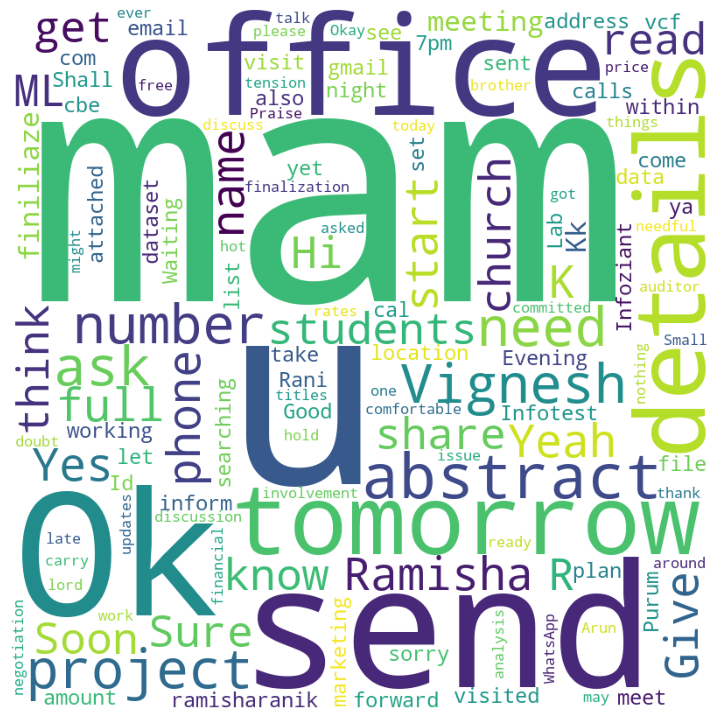

Successfully created


In [54]:

comment_words = []
stoplist = stopwords.words('english')
stoplist.extend(['omitted', 'voice','missed','call','video','deleted','media','message'])
wordcloudss="This function saves image"
dataset.index=range(dataset.shape[0])
for i in range(1,len(dataset)): 
    comment_words.append(dataset['Chat'][i])
    vv=" ".join(comment_words)          
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      stopwords = stoplist, 
                                      min_font_size = 10).generate(vv)         
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.savefig('wordcloud.PNG')
plt.show() 
print("Successfully created")
wordcloudss="This function saves image"


# NLP Assignment Enhancements

## 1. Flirt Prediction Model
- Problem Statement
- CountVectorizer + Classifier
- TF-IDF + Classifier
- Model Comparison
- Final Model Selection


In [62]:
# Flirt Prediction Model

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Example labeled data (replace with actual flirt dataset)
# flirt_df = df[['Chat']].copy()
# flirt_df['label'] = 0

flirt_df = pd.DataFrame({
    'Chat': [
        'Hey Baby',
        'I love you',
        'Miss you dear',
        'You look beautiful',
        'Meeting at 5 PM',
        'Project completed',
        'Please send the report'
    ],
    'label': [1,1,1,1,0,0,0]
})

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(flirt_df['Chat'])

model = LogisticRegression()
model.fit(X, flirt_df['label'])

flirt_df['Flirt_Prediction'] = model.predict(X)

print(flirt_df)


                     Chat  label  Flirt_Prediction
0                Hey Baby      1                 1
1              I love you      1                 1
2           Miss you dear      1                 1
3      You look beautiful      1                 1
4         Meeting at 5 PM      0                 0
5       Project completed      0                 0
6  Please send the report      0                 0


In [63]:
# Talkative vs Less Talkative

user_stats = df['Name'].value_counts()
print('Most Talkative User:', user_stats.idxmax())
print('Least Talkative User:', user_stats.idxmin())
user_stats


Most Talkative User:  AR❤
Least Talkative User:  Mabel Infoziant


Name
AR❤                27
Mabel Infoziant    23
Name: count, dtype: int64

In [64]:
# Most Active Day and Time

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Day'] = df['Date'].dt.day_name()

most_active_day = df['Day'].value_counts()
print(most_active_day.head())

df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
print(df['Hour'].value_counts().head())


Day
Sunday       27
Thursday     12
Wednesday     5
Monday        3
Saturday      3
Name: count, dtype: int64
Hour
13    16
12    11
14     6
15     5
20     4
Name: count, dtype: int64


C:\Users\kgopi\AppData\Local\Temp\ipykernel_9328\1921114970.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
C:\Users\kgopi\AppData\Local\Temp\ipykernel_9328\1921114970.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour


In [65]:
# Media Count by Person

media_df = df[df['Chat'].str.contains('omitted', case=False, na=False)]
media_count = media_df.groupby('Name').size()
media_count


Series([], dtype: int64)

In [66]:
# Missed Calls Analysis

missed_calls = df[df['Chat'].str.contains('missed call', case=False, na=False)]
missed_calls.groupby('Name').size()


Series([], dtype: int64)

In [67]:
# LDA Topic Modeling (instead of NMF)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cv = CountVectorizer(stop_words='english')
doc_term = cv.fit_transform(df['Chat'].fillna(''))

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(doc_term)

for idx, topic in enumerate(lda.components_):
    print(f'Topic {idx+1}:')
    print([cv.get_feature_names_out()[i] for i in topic.argsort()[-10:]])


Topic 1:
['visited', 'purum', 'start', 'tomorrow', 'abstracts', 'send', 'sure', 'office', 'ok', 'mam']
Topic 2:
['brother', 'doubt', 'praise', 'small', 'yeah', 'kk', 'abstract', 'read', 'ask', 'mam']
Topic 3:
['vignesh', 'number', 'hi', 'yes', 'just', 'know', 'need', 'send', 'tomorrow', 'details']
Topic 4:
['shall', 'rani', 'asked', 'comfortable', 'negotiation', 'price', 'think', 'finiliaze', 'project', 'mam']
Topic 5:
['tension', 'ma', 'hot', 'soon', 'ml', 'vignesh', 'ramisha', 'hi', 'church', 'meeting']
